<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/spectre_atome_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spectre de raies d'émission d'un atome

Ce notebook trace le spectre de raies d'émission visible d'un élément atomique
à partir du fichier **wavelength_tables_crop.csv** du site [atomic-spectra.net](https://www.atomic-spectra.net)
(données CC0 / domaine public).
Code adapté de l'auteur original David Alberto (www.astrolabe-science.fr).

Les données NIST brutes posent deux problèmes :
- La colonne `intens` est une échelle logarithmique discrète et saturée (plusieurs raies partagent la même valeur plafond)
- Le fichier CSV contient tous les états d'ionisation mélangés (Ne I à Ne IX)

atomic-spectra.net résout ces deux problèmes :
- La colonne **`Est. Visual Brightness`** est une intensité visuelle estimée, arbitrée entre deux sources, qui reflète ce qu'on observe réellement à l'œil ou au spectroscope
- Chaque raie est correctement étiquetée `Element` + `Spectrum` (I = atome neutre)

### Format du fichier source
```
Wavelength (Å)  |  Element  |  Spectrum  |  Rel. Intensity  |  Est. Visual Brightness  |  ...
```
Les longueurs d'onde sont en **Angströms** (÷10 → nm).

## 1. Imports

In [1]:
# ── Bibliothèques standard ──────────────────────────────────────────────────
import io

# ── Calcul & données ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ───────────────────────────────────────────────────────────
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Colab ────────────────────────────────────────────────────────────────────
from google.colab import files
from IPython.display import display

%matplotlib inline

## 2. Configuration

In [8]:
# ── Élément à tracer ─────────────────────────────────────────────────────────
# Symbole chimique et état d'ionisation (I = atome neutre)
SYMBOLE   = 'Ne'    # ← à changer : 'H', 'Na', 'Fe', 'Ar'...
IONISATION = 'I'    # I = neutre, II = ionisé une fois, etc.

# ── Plage spectrale (nm) ─────────────────────────────────────────────────────
XMIN, XMAX = 360, 750

# ── Nombre maximum de raies retenues ─────────────────────────────────────────
N_RAIES = 30

# ── Seuil d'intensité relative minimale (0–1) ────────────────────────────────
FILTRE = 0.001

# ── Résolution de regroupement des composantes fines (nm) ───────────────────
RESOLUTION = 0.05

# ── Épaisseur des raies ──────────────────────────────────────────────────────
EPAISSEUR = 1.2

# ── Dimensions de la figure (cm) ────────────────────────────────────────────
LARGEUR_CM, HAUTEUR_CM = 30, 10

# ── Police ───────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'DejaVu Sans'

## 3. Chargement du fichier wavelength_tables_crop.csv

In [3]:
# Upload du fichier wavelength_tables_crop.csv depuis votre PC
# (ou adapter le chemin si déjà sur Drive)
uploaded = files.upload()
nom_fichier = list(uploaded.keys())[0]

df_all = pd.read_csv(io.BytesIO(uploaded[nom_fichier]))
print(f"Fichier chargé : {nom_fichier}")
print(f"Nombre total de raies : {len(df_all)}")
print(f"Colonnes : {df_all.columns.tolist()}")

Saving wavelength_tables_crop.csv to wavelength_tables_crop.csv
Fichier chargé : wavelength_tables_crop.csv
Nombre total de raies : 46575
Colonnes : ['Wavelength, Å', 'Element', 'Spectrum', 'Rel. Intensity', 'Est. Visual Brightness', 'Lower Config', 'Lower Term+J', 'Lower Level', 'Upper Config', 'Upper Term+J', 'Upper Level']


## 4. Fonctions de traitement

In [9]:
def extraire_element(df, symbole, ionisation='I', xmin=XMIN, xmax=XMAX):
    """
    Filtre le DataFrame global pour ne garder que les raies de l'élément
    souhaité à l'état d'ionisation voulu, dans la fenêtre spectrale [xmin, xmax] nm.
    Convertit les longueurs d'onde de l'Angström vers le nm (÷10).
    """
    df = df.copy()
    df['wl_nm'] = pd.to_numeric(df['Wavelength, Å'], errors='coerce') / 10.0
    masque = (
        (df['Element'] == symbole) &
        (df['Spectrum'] == ionisation) &
        (df['wl_nm'] >= xmin) &
        (df['wl_nm'] <= xmax)
    )
    return df[masque].copy()


def calculer_score(data):
    """
    Calcule un score d'intensité pour chaque raie en combinant :
      1. Est. Visual Brightness : intensité visuelle estimée par atomic-spectra.net,
         arbitrée entre deux sources — reflète ce qu'on voit au spectroscope.
         Disponible pour ~80% des raies visibles.
      2. Rel. Intensity (fallback) : intensité relative NIST, en unités arbitraires.
         Pondérée à 10% du max visuel pour ne pas écraser les raies avec Visual.

    Le '-' dans Est. Visual Brightness est interprété comme NaN par pandas
    grâce au paramètre errors='coerce'.
    """
    data = data.copy()
    data['vis'] = pd.to_numeric(
        data['Est. Visual Brightness'].astype(str).str.strip(),
        errors='coerce'
    )
    data['rel'] = pd.to_numeric(
        data['Rel. Intensity'].astype(str).str.strip(),
        errors='coerce'
    )
    vis_max = data['vis'].max()
    rel_max = data['rel'].max()

    # Fallback Rel. Intensity normalisé à 10% du max visuel
    fallback = (data['rel'] / rel_max * vis_max * 0.1) if rel_max > 0 else 0
    data['score'] = data['vis'].fillna(fallback)
    return data[data['score'] > 0]


def filtrage_top_n(data, n=N_RAIES, seuil=FILTRE, resolution=RESOLUTION):
    """
    Regroupe les composantes de structure fine par fenêtre de 'resolution' nm
    en sommant leurs scores, sélectionne les n raies les plus intenses,
    normalise entre 0 et 1, élimine les raies sous le seuil relatif.
    """
    data = data.copy()
    data['wl_g'] = (data['wl_nm'] / resolution).round() * resolution
    grouped = data.groupby('wl_g', as_index=False).agg(
        wl=('wl_nm', 'mean'),
        score=('score', 'sum')
    )
    top = grouped.sort_values('score', ascending=False).head(n).copy()
    top['int'] = top['score'] / top['score'].max()
    return top[top['int'] >= seuil]

## 5. Extraction et traitement

In [10]:
df_elem = extraire_element(df_all, SYMBOLE, IONISATION)
print(f"{SYMBOLE} {IONISATION} dans {XMIN}–{XMAX} nm : {len(df_elem)} raies")

df_elem = calculer_score(df_elem)
n_vis = (df_elem['vis'] > 0).sum()
n_rel = (df_elem['vis'].isna()).sum()
print(f"  score depuis Est. Visual Brightness : {n_vis} raies")
print(f"  score depuis Rel. Intensity (fallback) : {n_rel} raies")

df_plot = filtrage_top_n(df_elem)
print(f"\nRaies retenues après filtrage : {len(df_plot)}")
print(df_plot.sort_values('wl')[['wl', 'int']].to_string(index=False))

Ne I dans 360–750 nm : 596 raies
  score depuis Est. Visual Brightness : 477 raies
  score depuis Rel. Intensity (fallback) : 119 raies

Raies retenues après filtrage : 30
       wl      int
540.05616 0.158627
585.24878 1.000000
588.18950 0.331442
591.36330 0.059024
591.89679 0.056754
594.48340 0.272134
596.54710 0.127696
597.46273 0.061578
597.55343 0.072361
598.79074 0.048524
602.99968 0.212259
607.43376 0.408343
609.61630 0.556754
614.25080 0.061862
614.30627 0.660329
616.35937 0.412032
618.21460 0.143871
621.72812 0.150114
626.64952 0.360102
630.47893 0.052497
631.36855 0.114642
632.81646 0.099319
633.44276 0.140465
638.29914 0.223326
640.22480 0.860953
640.97469 0.061010
650.65277 0.171680
659.89528 0.072645
665.20925 0.101873
667.83036 0.077753


## 6. Tracé du spectre

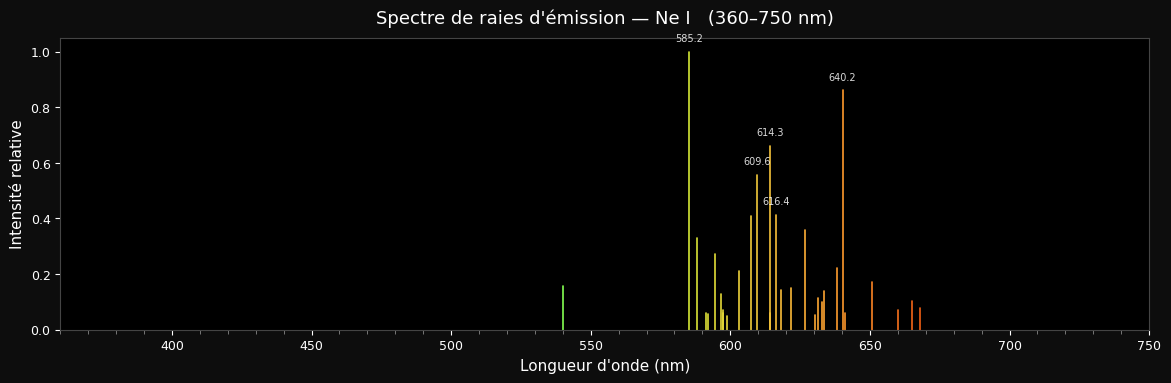

In [11]:
cmap = plt.get_cmap('turbo')
norm = mpl.colors.Normalize(vmin=XMIN, vmax=XMAX)

fig, ax = plt.subplots(figsize=(LARGEUR_CM / 2.54, HAUTEUR_CM / 2.54))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('black')

for _, row in df_plot.iterrows():
    ax.plot(
        [row.wl, row.wl], [0, row['int']],
        lw=EPAISSEUR,
        color=cmap(norm(row.wl)),
        solid_capstyle='round'
    )

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Longueur d'onde (nm)", color='white', fontsize=11)
ax.set_ylabel("Intensité relative", color='white', fontsize=11)
ax.tick_params(colors='white', labelsize=9)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
ax.tick_params(which='minor', length=3, color='#888888')
for spine in ax.spines.values():
    spine.set_color('#444444')

ax.set_title(
    f"Spectre de raies d'émission — {SYMBOLE} {IONISATION}   ({XMIN}–{XMAX} nm)",
    color='white', fontsize=13, pad=10
)

# Annotation des 5 raies les plus intenses
for _, row in df_plot.nlargest(5, 'int').iterrows():
    ax.annotate(
        f"{row.wl:.1f}",
        xy=(row.wl, row['int']),
        xytext=(0, 6),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=7, color='white', alpha=0.85
    )

plt.tight_layout()
plt.show()

## 7. Sauvegarde

In [7]:
fig.savefig(f'spectre_{SYMBOLE}{IONISATION}.pdf', bbox_inches='tight', dpi=150)
fig.savefig(f'spectre_{SYMBOLE}{IONISATION}.png', bbox_inches='tight', dpi=250)
print(f"Sauvegardé : spectre_{SYMBOLE}{IONISATION}.pdf  et  .png")

files.download(f'spectre_{SYMBOLE}{IONISATION}.png')
files.download(f'spectre_{SYMBOLE}{IONISATION}.pdf')

Sauvegardé : spectre_NaI.pdf  et  .png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>